# Décomposition spectrale du noyau \|x - y\|

Ce notebook met en place une première application numérique du papier sur la réplication statique des payoffs européens.

L'objectif est simple : calculer les premiers termes de l'eigensystème du noyau straddle `G(x,y)=|x-y|`, puis afficher un tableau lisible avec `n`, `lambda_n`, `omega_n`, `c_n` et la norme d'erreur de troncature en `L^2`.

## 1. Rappel théorique

Sur l'intervalle `[0,1]`, les fonctions propres du noyau straddle sont explicites.

- `omega_0` est la racine positive de `coth(omega)=omega`.
- Pour `n` impair, `omega_n = n*pi/2`.
- Pour `n` pair, `omega_n` est la racine de `cot(omega) = -omega` sur l'intervalle approprié.

Les valeurs propres sont ensuite données par

$$
lambda_0 = \frac{1}{2\omega_0^2}, \qquad \lambda_n = -\frac{1}{2\omega_n^2} \quad \text{pour } n\ge 1.
$$

In [ ]:
import numpy as np
import pandas as pd
from scipy.optimize import root_scalar
from IPython.display import display
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda x: f"{x:.12f}")

## 2. Fonctions numériques

On code les fréquences `omega_n`, les valeurs propres `lambda_n`, les coefficients `c_n` du développement spectral, puis les fonctions propres `phi_n`.

In [28]:
def omega0():
    """Positive root of coth(w) = w."""
    f = lambda w: 1.0 / np.tanh(w) - w
    sol = root_scalar(f, bracket=[1e-10, 10.0], method="brentq")
    return sol.root

def omega_even(n):
    """For even n >= 2, solve cot(w) = -w."""
    a = (n - 1) * np.pi / 2 + 1e-10
    b = n * np.pi / 2 - 1e-10
    f = lambda w: 1.0 / np.tan(w) + w
    sol = root_scalar(f, bracket=[a, b], method="brentq")
    return sol.root

def omega_n(n):
    if n == 0:      return omega0()
    if n % 2 == 1:  return n * np.pi / 2
    return omega_even(n)


def lambda_n(n):
    w = omega_n(n)
    if n == 0: return 1.0 / (2.0 * w**2)
    return -1.0 / (2.0 * w**2)

def c_n(n):
    w = omega_n(n)
    if n == 0:
        return 1.0 / (w * np.cosh(w))**2
    if n % 2 == 1:
        return -4.0 / (n * np.pi)**2
    return -1.0 / (w * np.cos(w))**2

def phi_n(n, x):
    x = np.asarray(x)
    if n == 0:
        w = omega_n(0)
        return np.sqrt(2.0) / np.cosh(w) * np.cosh(w * (1.0 - 2.0 * x))
    if n % 2 == 1:
        return np.sqrt(2.0) * np.cos(n * np.pi * x)
    w = omega_n(n)
    return np.sqrt(2.0) / np.cos(w) * np.cos(w * (1.0 - 2.0 * x))

## 3. Tableau des premiers termes

On affiche `lambda_n` à l'échelle `10^-3`, comme dans le papier, et on arrondit l'erreur de troncature à 6 décimales.

L'erreur `error_norm_L2` correspond à

$$
\left\|\sum_{k=n+1}^{\infty} \lambda_k \phi_k\right\|_{L^2} = \sqrt{\sum_{k=n+1}^{\infty} \lambda_k^2}.
$$

In [29]:
def build_spectral_table(N=20, tail_terms=20000):
    """Build a dataframe with n, lambda_n, omega_n, c_n, error_norm_L2."""
    lambdas = np.array([lambda_n(k) for k in range(tail_terms)], dtype=float)

    rows = []
    for n in range(N):
        err_l2 = np.sqrt(np.sum(lambdas[n + 1:] ** 2))
        rows.append({
            "n": n,
            "lambda_n (x10^-3)": lambda_n(n) * 1e3,
            "omega_n": omega_n(n),
            "c_n": c_n(n),
            "error_norm_L2": round(err_l2, 6)})
    return pd.DataFrame(rows)


table = build_spectral_table(N=20, tail_terms=20000)

styled_table = (
    table.style
    .hide(axis="index")
    .format({
        "lambda_n (x10^-3)": "{:.6f}",
        "omega_n": "{:.9f}",
        "c_n": "{:.9f}",
        "error_norm_L2": "{:.6f}",
    })
    .set_properties(**{"text-align": "right"})
    .set_table_styles([
        {"selector": "th", "props": [("text-align", "center"), ("font-weight", "bold")]},
        {"selector": "table", "props": [("border-collapse", "collapse"), ("width", "100%")]},
        {"selector": "td, th", "props": [("padding", "6px 10px")]},
    ])
)

display(styled_table)

n,lambda_n (x10^-3),omega_n,c_n,error_norm_L2
0,347.408269,1.199678640,0.212046517,0.214416
1,-202.642367,1.570796327,-0.405284735,0.070073
2,-63.849096,2.798386046,-0.144005020,0.028871
3,-22.515819,4.712388980,-0.045031637,0.018071
4,-13.344113,6.121250467,-0.027400487,0.012186
5,-8.105695,7.853981634,-0.016211389,0.009099
6,-5.758867,9.317866462,-0.011650392,0.007045
7,-4.135559,10.995574288,-0.008271117,0.005703
8,-3.206947,12.486454395,-0.006455031,0.004716
9,-2.501758,14.137166941,-0.005003515,0.003998


## 4. Vérification rapide du noyau

En bonus, on peut reconstruire `|x-y|` avec un nombre fini de modes et vérifier visuellement que l'approximation s'améliore quand on ajoute des termes.

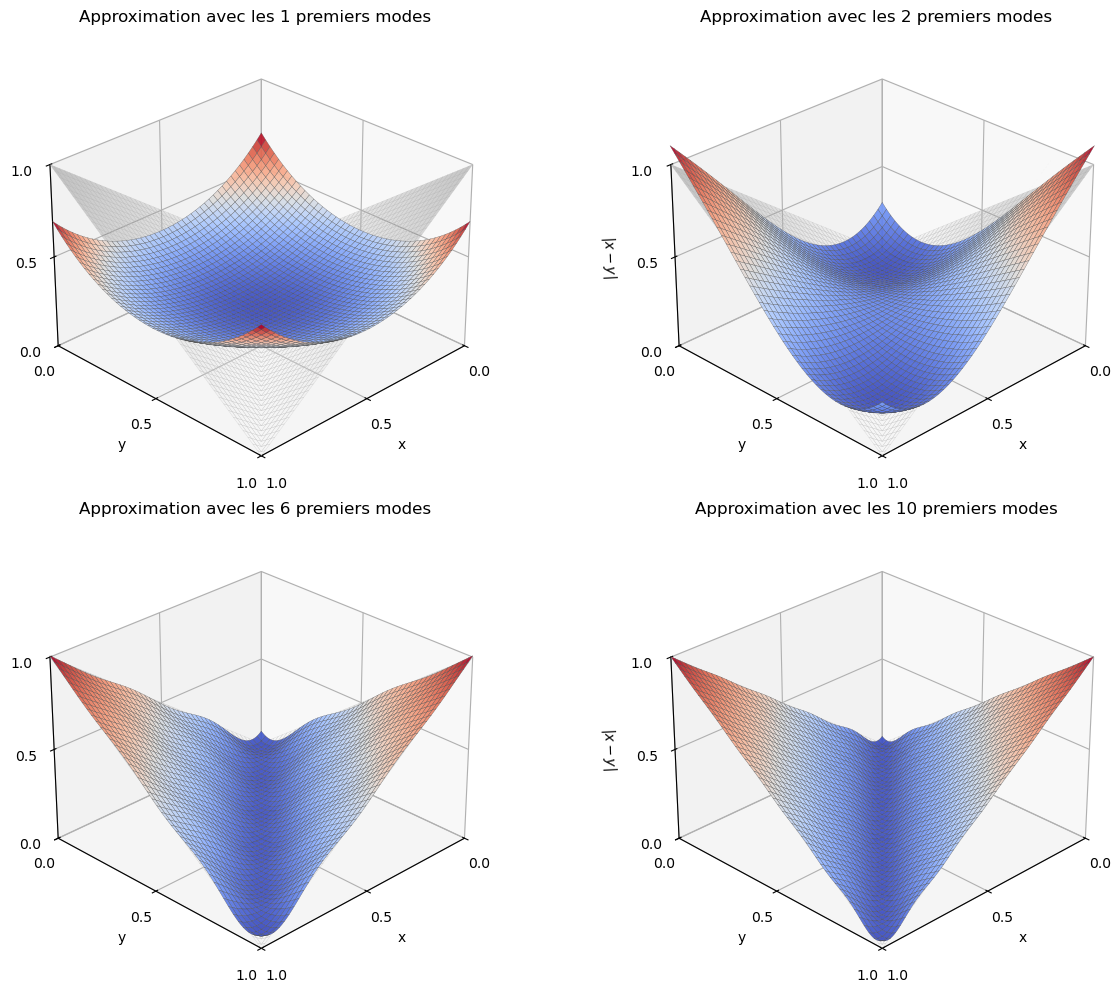

In [39]:
# ============================================================
# 4. Visualisation des approximations spectrales du noyau
# ============================================================

def kernel_approx(X, Y, N):
    K = np.zeros_like(X, dtype=float)
    for k in range(N):
        K += lambda_n(k) * phi_n(k, X) * phi_n(k, Y)
    return K


# Domaine
a, b = 0.0, 1.0
n = 180

# Grille
x = np.linspace(a, b, n)
y = np.linspace(a, b, n)
X, Y = np.meshgrid(x, y)

# Noyau exact
K_exact = np.abs(X - Y)

# Niveaux d'approximation
levels = [1, 2, 6, 10]
K_approx = {N: kernel_approx(X, Y, N) for N in levels}

# Figure
fig = plt.figure(figsize=(14, 10))
fig.patch.set_facecolor("white")

for i, N in enumerate(levels, start=1):
    ax = fig.add_subplot(2, 2, i, projection="3d")

    # Noyau exact en fond
    ax.plot_surface(
        X, Y, K_exact,
        cmap="Greys",
        edgecolor="0.75",
        linewidth=0.15,
        alpha=0.20,
        shade=False
    )

    # Approximation spectrale par-dessus
    ax.plot_surface(
        X, Y, K_approx[N],
        cmap="coolwarm",
        edgecolor="0.30",
        linewidth=0.20,
        alpha=0.92,
        shade=False
    )

    ax.set_title(f"Approximation avec les {N} premiers modes", pad=12)
    ax.set_xlabel("x", labelpad=6)
    ax.set_ylabel("y", labelpad=6)
    ax.set_zlabel(r"$|x-y|$", labelpad=6)

    ax.view_init(elev=28, azim=45)
    ax.set_box_aspect((1, 1, 0.7))
    ax.set_xlim(a, b)
    ax.set_ylim(a, b)
    ax.set_zlim(0, 1)

    ax.set_xticks([0.0, 0.5, 1.0])
    ax.set_yticks([0.0, 0.5, 1.0])
    ax.set_zticks([0.0, 0.5, 1.0])

plt.tight_layout()
plt.show()

## 5.1. Benefits for option replication and hedging

We compare the spectroreplication method with a classical Fourier cosine expansion (COS method) on two European payoffs of high practical relevance: the **log contract** and the **vanilla call**.

The proxies used in the comparison are:

$$
\widehat{F}_n(x) := c + qx + \sum_{k=0}^{n-1} w_k \phi_k(x),
$$

for the spectroreplication method, and

$$
\breve{F}_n(x) := \langle F, \psi_0 \rangle + 2 \sum_{k=1}^{n-1} \langle F, \psi_k \rangle \psi_k(x),
$$

for the Fourier cosine series, where

$$
\psi_k(x) = \cos(k\pi x), \qquad k \ge 0.
$$

---

### Log contract

We first consider the log contract

$$
F(x) = \ln(x + 0.01),
$$

on the interval $[0.01, 1.01]$.

The figure below compares the $L^2$ error decay as the truncation order $n$ increases.

- The **spectroreplication** curve corresponds to the approximation based on the eigenfunctions of the straddle kernel.
- The **Fourier series** curve corresponds to the COS approximation.

For this payoff, the spectroreplication method converges faster and becomes more accurate than the Fourier series for sufficiently large $n$.

---

### Vanilla calls

We now consider the standard vanilla call payoff

$$
F(x) = (x-K)^+,
$$

for strikes $K \in [0,1]$.

For each truncation order $n$, we compute the average $L^2$ error over all strikes and compare the two methods in the table below.

- **Spectroreplication**: average error of the spectroreplication proxy.
- **Fourier series**: average error of the Fourier cosine proxy.
- **Ratio**:
  
$$
\text{Ratio} = \frac{\text{Spectroreplication error}}{\text{Fourier error}}.
$$

A ratio smaller than $1$ means that spectroreplication is more accurate.

---

### Error as a function of the strike

We also plot the $L^2$ error for a fixed truncation order $n=10$ as a function of the strike $K$.

This curve shows how the approximation quality changes across the strike domain and gives a more detailed view of the behaviour of both methods.

---

### Conclusion

On these two important examples, the spectroreplication method performs at least as well as, and often better than, the Fourier cosine expansion for moderate truncation orders.

This suggests that the eigenfunctions of the straddle kernel provide an efficient basis for approximating certain European payoffs, especially when the target payoff has limited smoothness or when a small number of terms is desired.

In [ ]:
trap = getattr(np, "trapezoid", np.trapz)  # compatibilité NumPy

# ============================================================
# Helpers
# ============================================================
def c_q_from_endpoints(F, Fp, a, b):
    c = 0.5 * (F(a) + F(b) - a * Fp(a) - b * Fp(b))
    q = 0.5 * (Fp(a) + Fp(b))
    return c, q

def straddle_basis_matrix(x, n, a):
    u = x - a
    return np.vstack([phi_n(k, u) for k in range(n)])

def cosine_basis_matrix(x, n, a):
    u = x - a
    return np.vstack([np.cos(k * np.pi * u) for k in range(n)])

def l2_errors(x, F, approximations):
    return np.sqrt(trap((F[None, :] - approximations) ** 2, x, axis=1))

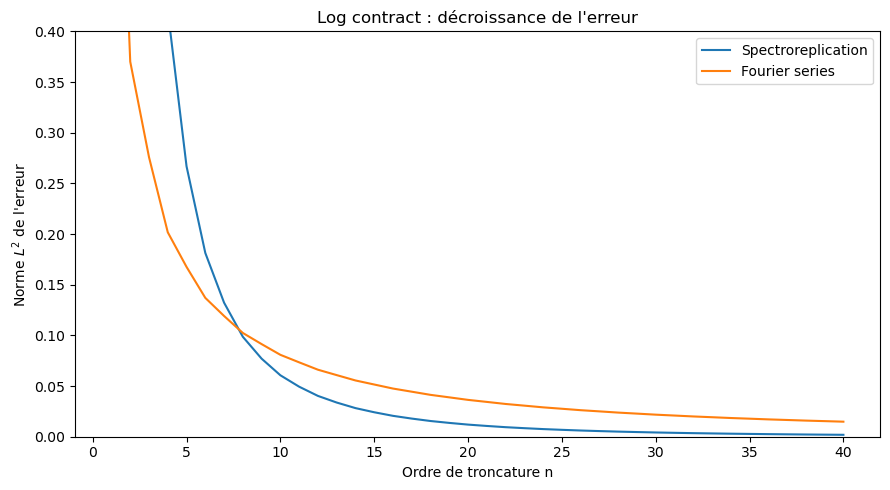

In [62]:
# ============================================================
# 1) Figure 2a : log contract
# ============================================================
def log_contract_error_curves(max_n=40, a=0.01, b=1.01, grid_size=16384):
    x = np.linspace(a, b, grid_size)

    F = np.log(x + 0.01)
    Fp = lambda t: 1.0 / (t + 0.01)
    Fpp = -1.0 / (x + 0.01) ** 2

    c, q = c_q_from_endpoints(lambda t: np.log(t + 0.01), Fp, a, b)

    # Spectroreplication
    spec_basis = straddle_basis_matrix(x, max_n, a)
    lambdas = np.array([lambda_n(k) for k in range(max_n)])
    spec_weights = 0.5 * lambdas * trap(spec_basis * Fpp, x, axis=1)
    spec_approxs = c + q * x + np.cumsum(spec_weights[:, None] * spec_basis, axis=0)
    spec_err = l2_errors(x, F, spec_approxs)

    # Fourier series
    four_basis = cosine_basis_matrix(x, max_n, a)
    four_coeffs = np.zeros(max_n)
    four_coeffs[0] = trap(F, x)
    if max_n > 1:
        four_coeffs[1:] = 2.0 * trap(F * four_basis[1:], x, axis=1)
    four_approxs = np.cumsum(four_coeffs[:, None] * four_basis, axis=0)
    four_err = l2_errors(x, F, four_approxs)

    return np.arange(1, max_n + 1), spec_err, four_err


ns, log_spec_err, log_four_err = log_contract_error_curves(max_n=40)

plt.figure(figsize=(9, 5))
plt.plot(ns, log_spec_err, label="Spectroreplication")
plt.plot(ns, log_four_err, label="Fourier series")
plt.xlabel("Ordre de troncature n")
plt.ylabel(r"Norme $L^2$ de l'erreur")
plt.title("Log contract : décroissance de l'erreur")
plt.ylim(0, 0.4)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# 2) Calls vanilles : erreurs analytiques
# ============================================================
def fourier_call_coeffs(K, max_n):
    """
    Série cosinus sur [0,1] pour F(x) = (x-K)^+.
    Le coefficient k=0 est <F, psi0>.
    Les coefficients k>=1 sont 2 <F, psi_k>.
    """
    coeffs = np.zeros(max_n)
    coeffs[0] = 0.5 * (1.0 - K) ** 2

    if max_n > 1:
        k = np.arange(1, max_n)
        coeffs[1:] = 2.0 * (((-1.0) ** k) - np.cos(np.pi * k * K)) / (np.pi * k) ** 2
    return coeffs

def fourier_call_errors_exact(K, max_n):
    """
    Normes L2 exactes des proxys Fourier tronqués d'ordre 1..max_n
    pour F(x) = (x-K)^+ sur [0,1].
    """
    coeffs = fourier_call_coeffs(K, max_n)
    full_norm2 = (1.0 - K) ** 3 / 3.0

    energy = np.empty(max_n)
    energy[0] = coeffs[0] ** 2
    if max_n > 1:
        energy[1:] = coeffs[0] ** 2 + 0.5 * np.cumsum(coeffs[1:] ** 2)

    return np.sqrt(np.maximum(full_norm2 - energy, 0.0))


def spectro_call_errors_exact(K, max_n, Nspec=4000):
    """
    Approximation de l'erreur spectrale via la queue
    sqrt(sum_{k>=n} w_k^2), avec
    w_k = 1/2 * lambda_k * phi_k(K).
    """
    Nspec = max(Nspec, max_n + 50)
    k = np.arange(Nspec)

    lambdas = np.array([lambda_n(j) for j in k])
    phi_at_K = np.array([phi_n(j, K) for j in k])
    weights = 0.5 * lambdas * phi_at_K

    tail2 = np.cumsum(weights[::-1] ** 2)[::-1]
    return np.sqrt(tail2[1 : max_n + 1])


def call_error_matrix(max_n=40, strikes=None, Nspec=4000):
    if strikes is None:
        strikes = np.round(np.arange(0.0, 1.0 + 1e-9, 0.01), 3)

    spec_err = np.zeros((len(strikes), max_n))
    four_err = np.zeros((len(strikes), max_n))

    for i, K in enumerate(strikes):
        spec_err[i, :] = spectro_call_errors_exact(K, max_n, Nspec=Nspec)
        four_err[i, :] = fourier_call_errors_exact(K, max_n)

    return strikes, spec_err, four_err


strikes, call_spec_err, call_four_err = call_error_matrix(max_n=40, Nspec=4000)

orders = [5, 10, 15, 20, 25, 30, 35, 40]
rows = []

for n in orders:
    spec_mean = call_spec_err[:, n - 1].mean()
    four_mean = call_four_err[:, n - 1].mean()

    rows.append(
        {
            "n": n,
            "Spectroreplication": spec_mean,
            "Fourier series": four_mean,
            "Ratio": spec_mean / four_mean})

table = pd.DataFrame(rows)

display(table.style.hide(axis="index").format(
        {
            "Spectroreplication": "{:.6f}",
            "Fourier series": "{:.6f}",
            "Ratio": "{:.2f}"}))

n,Spectroreplication,Fourier series,Ratio
5,0.006015,0.010039,0.60
10,0.001989,0.003367,0.59
15,0.001058,0.001802,0.59
20,0.000679,0.001159,0.59
25,0.000483,0.000825,0.59
30,0.000366,0.000625,0.58
35,0.000289,0.000495,0.58
40,0.000236,0.000404,0.58


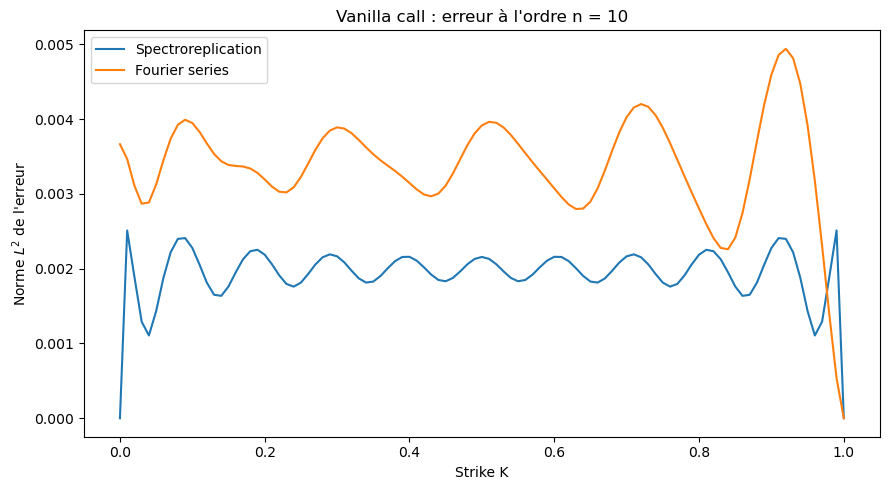

In [ ]:
# ============================================================
# 3) Figure 2b : erreur à n = 10 en fonction du strike
# ============================================================
plt.figure(figsize=(9, 5))
plt.plot(strikes, call_spec_err[:, 9], label="Spectroreplication")
plt.plot(strikes, call_four_err[:, 9], label="Fourier series")
plt.xlabel("Strike K")
plt.ylabel(r"Norme $L^2$ de l'erreur")
plt.title("Vanilla call : erreur à l'ordre n = 10")
plt.legend()
plt.tight_layout()
plt.show()